# **Question:**
#### How does the most common song key of songs in the lower 25% of streams in the 2023 Spotify list of "Most Streamed Songs" compare to the most common song key in songs in the top 25% of streams in the same Spotify list?

## **Type of Study**
##### This is a census study because we are looking at and finding information about just the most popular songs of 2023. All of the most-streamed songs from 2023 are included in this dataset, so it is not a sample but rather a population.

In [14]:
import pandas as pd
import seaborn as sb

In [15]:
songs = pd.read_csv("spotify-2023.csv", encoding = "latin-1")

In [16]:
#fix some formatting issues, a weird value + convert string-->numeric
songs = songs.drop(574)
songs["streams"] = pd.to_numeric(songs["streams"])

In [17]:
percent_75 = songs["streams"].quantile(0.75)
print(percent_75)
# songs with this value or higher are in the top 25% of streams of the popular songs
percent_25 = songs["streams"].quantile(0.25)
print(percent_25)
# songs with this value or lower are in the lower 25% of streams of the popular songs

673869022.0
141636175.0


In [18]:
top_songs = songs[songs["streams"] >= percent_75]
high = top_songs

In [19]:
low_songs = songs[songs["streams"] <= percent_25]
low = low_songs

In [20]:
key_frequencies_high = top_songs["key"].value_counts()
key_frequencies_low = low_songs["key"].value_counts()

In [21]:
# to make a combined histoplot, let's combine the low and high datasets by also add an identifying column for high/low streams:
top_songs["stream_group"] = "Top 25%"
low_songs["stream_group"] = "Bottom 25%"
combined_songs = pd.concat([top_songs, low_songs])

<Axes: xlabel='key', ylabel='Count'>

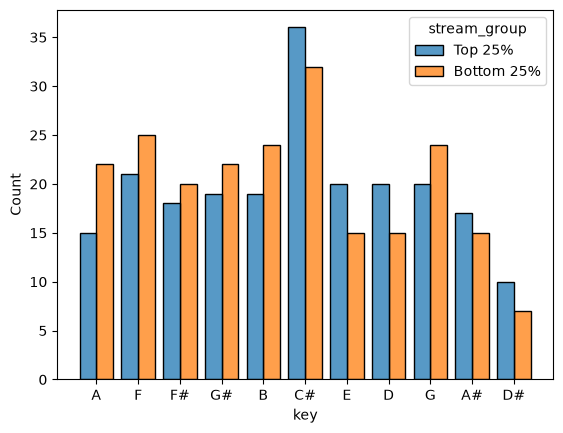

In [22]:
sb.histplot(
    data=combined_songs,
    x="key",
    hue="stream_group",
    multiple="dodge",
    shrink=0.8
)

In [28]:
# need to download low and high key frequencies to put into desmos, start with valuecounts found earlier
high = top_songs
low = low_songs
print(top_songs["key"].head(20))

3       A
6       F
12    NaN
14     F#
15     G#
22    NaN
26      B
32     C#
33      E
37      F
38      D
41      D
42      G
43     F#
46    NaN
47     C#
48      G
54      E
55     C#
57      G
Name: key, dtype: str


In [29]:
key_frequencies = {
    "C": 261.63,
    "C#": 277.18,
    "D": 293.66,
    "D#": 311.13,
    "E": 329.63,
    "F": 349.23,
    "F#": 369.99,
    "G": 392.00,
    "G#": 415.30,
    "A": 440.00,
    "A#": 466.16,
    "B": 493.88
}

In [30]:
high["Key-Freq"] = high["key"].map(key_frequencies)
low["Key-Freq"] = low["key"].map(key_frequencies)
print(high["Key-Freq"].head(20))

3     440.00
6     349.23
12       NaN
14    369.99
15    415.30
22       NaN
26    493.88
32    277.18
33    329.63
37    349.23
38    293.66
41    293.66
42    392.00
43    369.99
46       NaN
47    277.18
48    392.00
54    329.63
55    277.18
57    392.00
Name: Key-Freq, dtype: float64


In [32]:
high.to_excel("high.xlsx", index=True)
low.to_excel("low.xlsx", index=True)

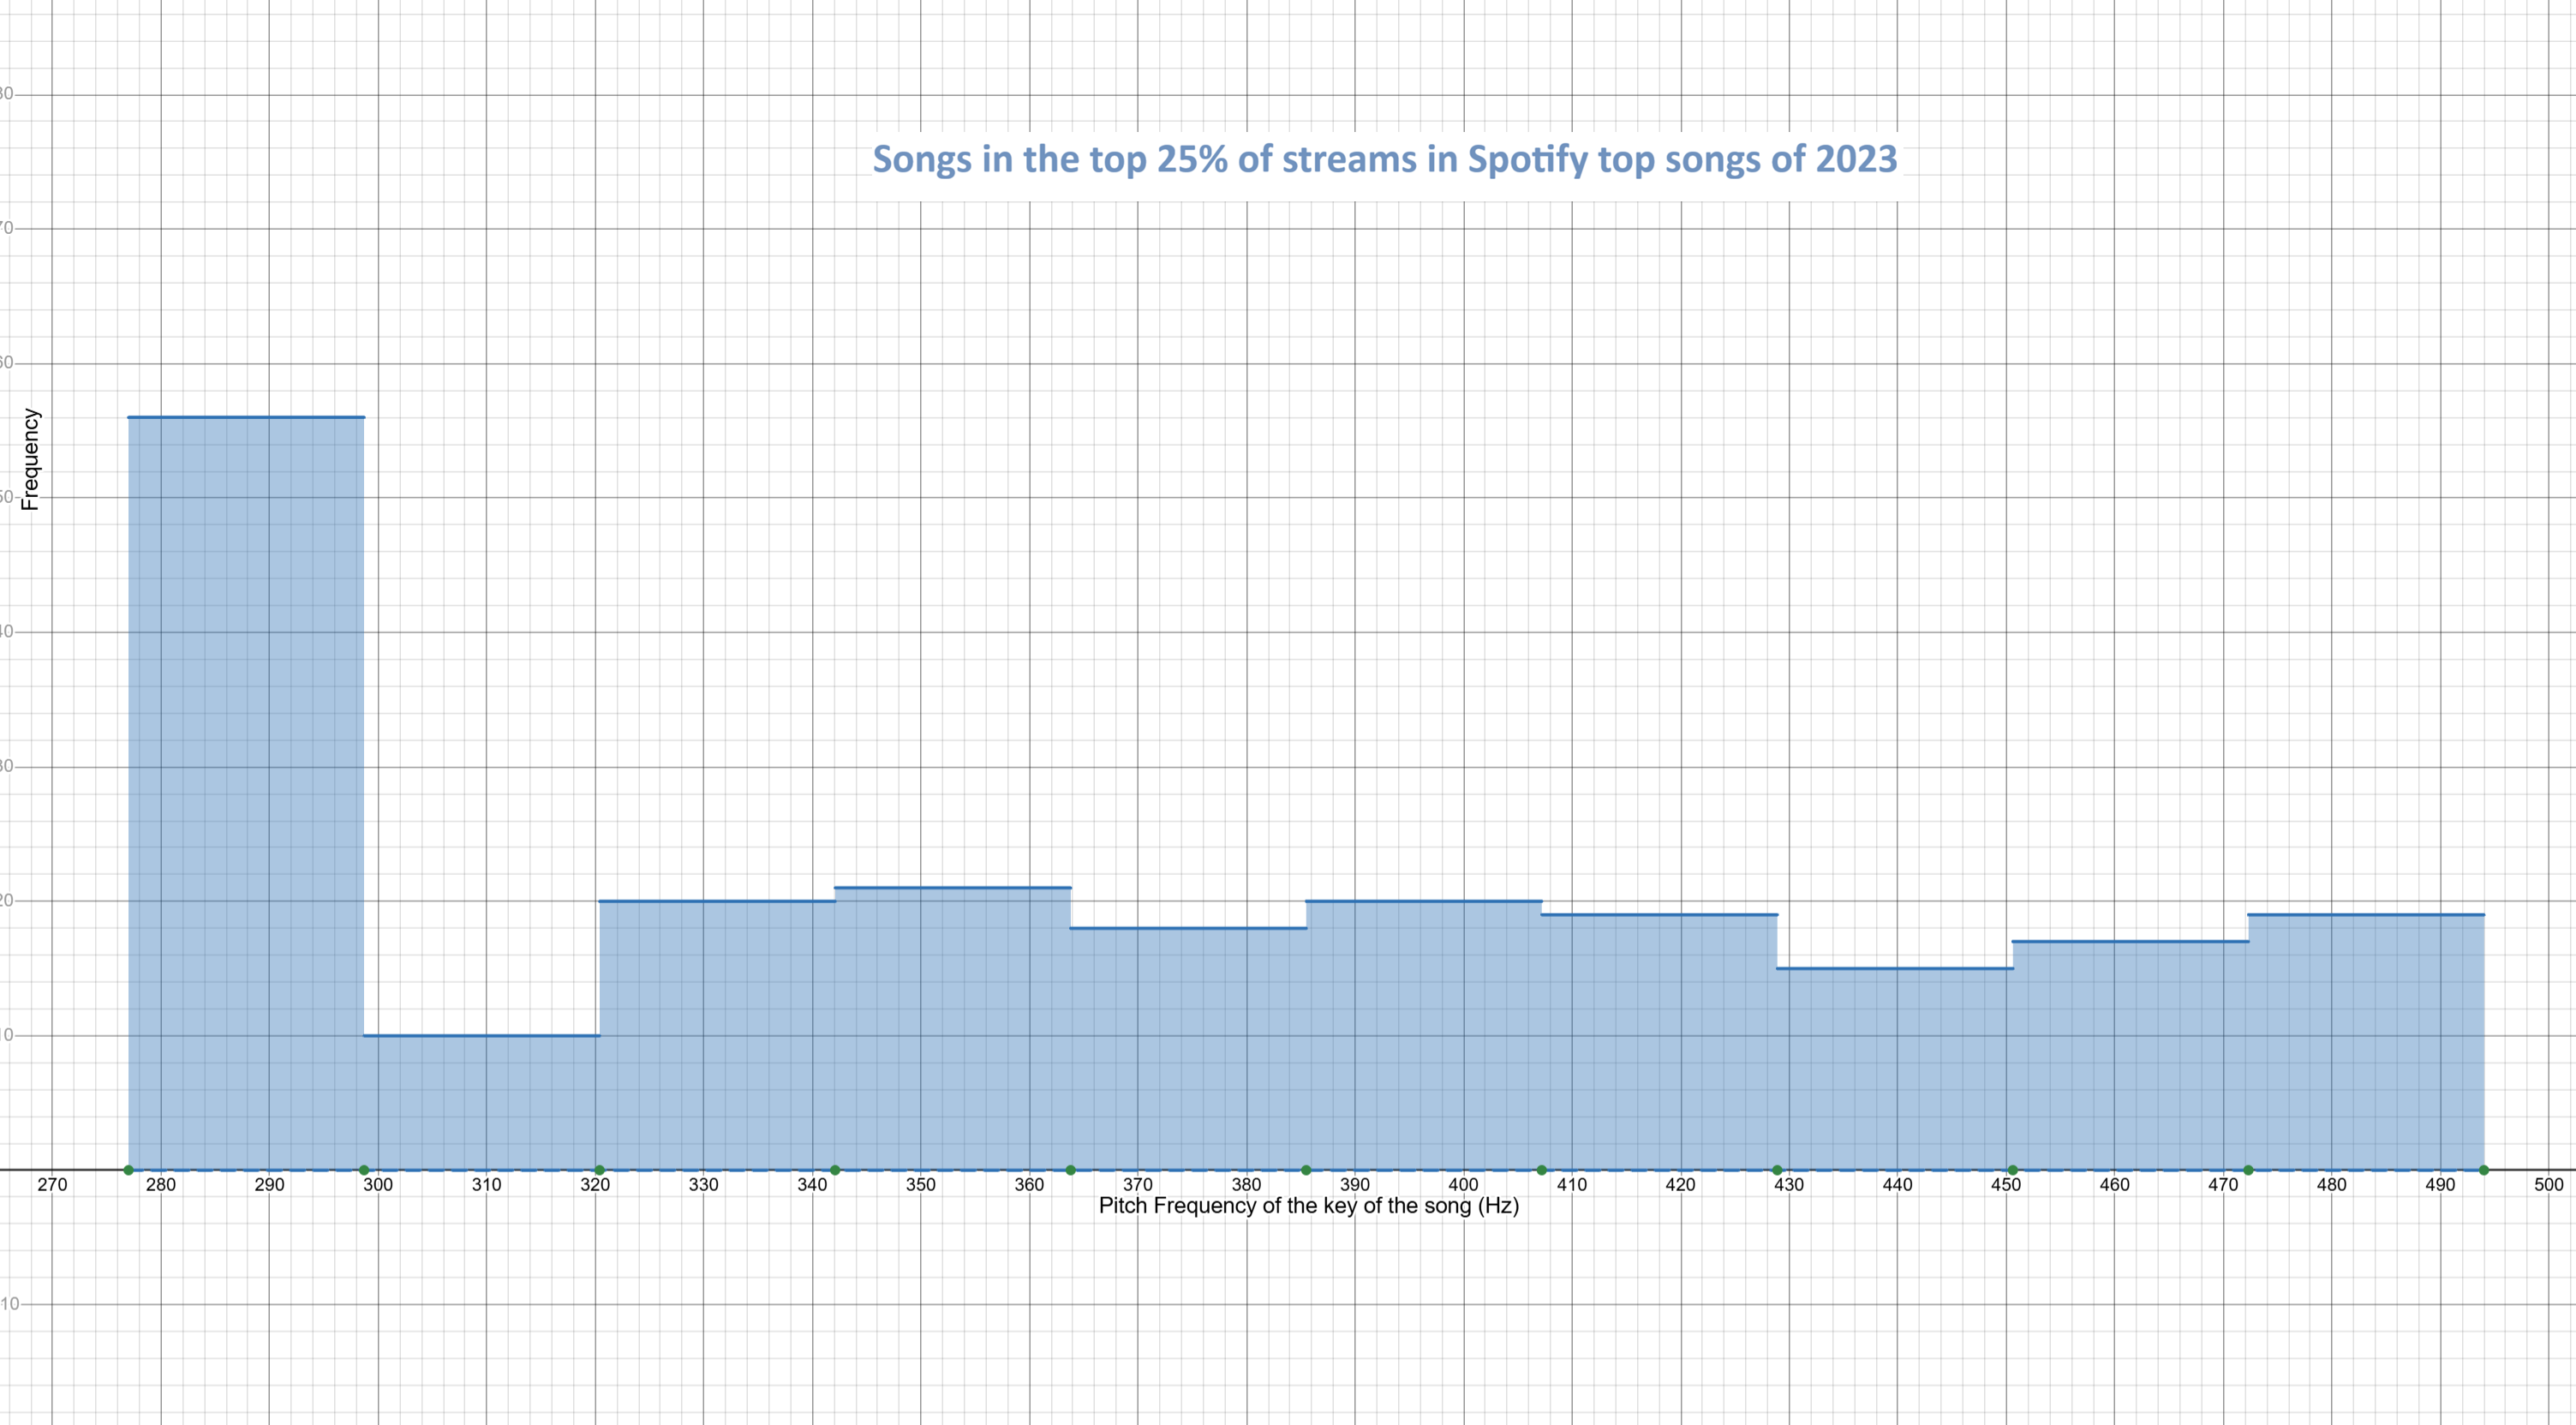
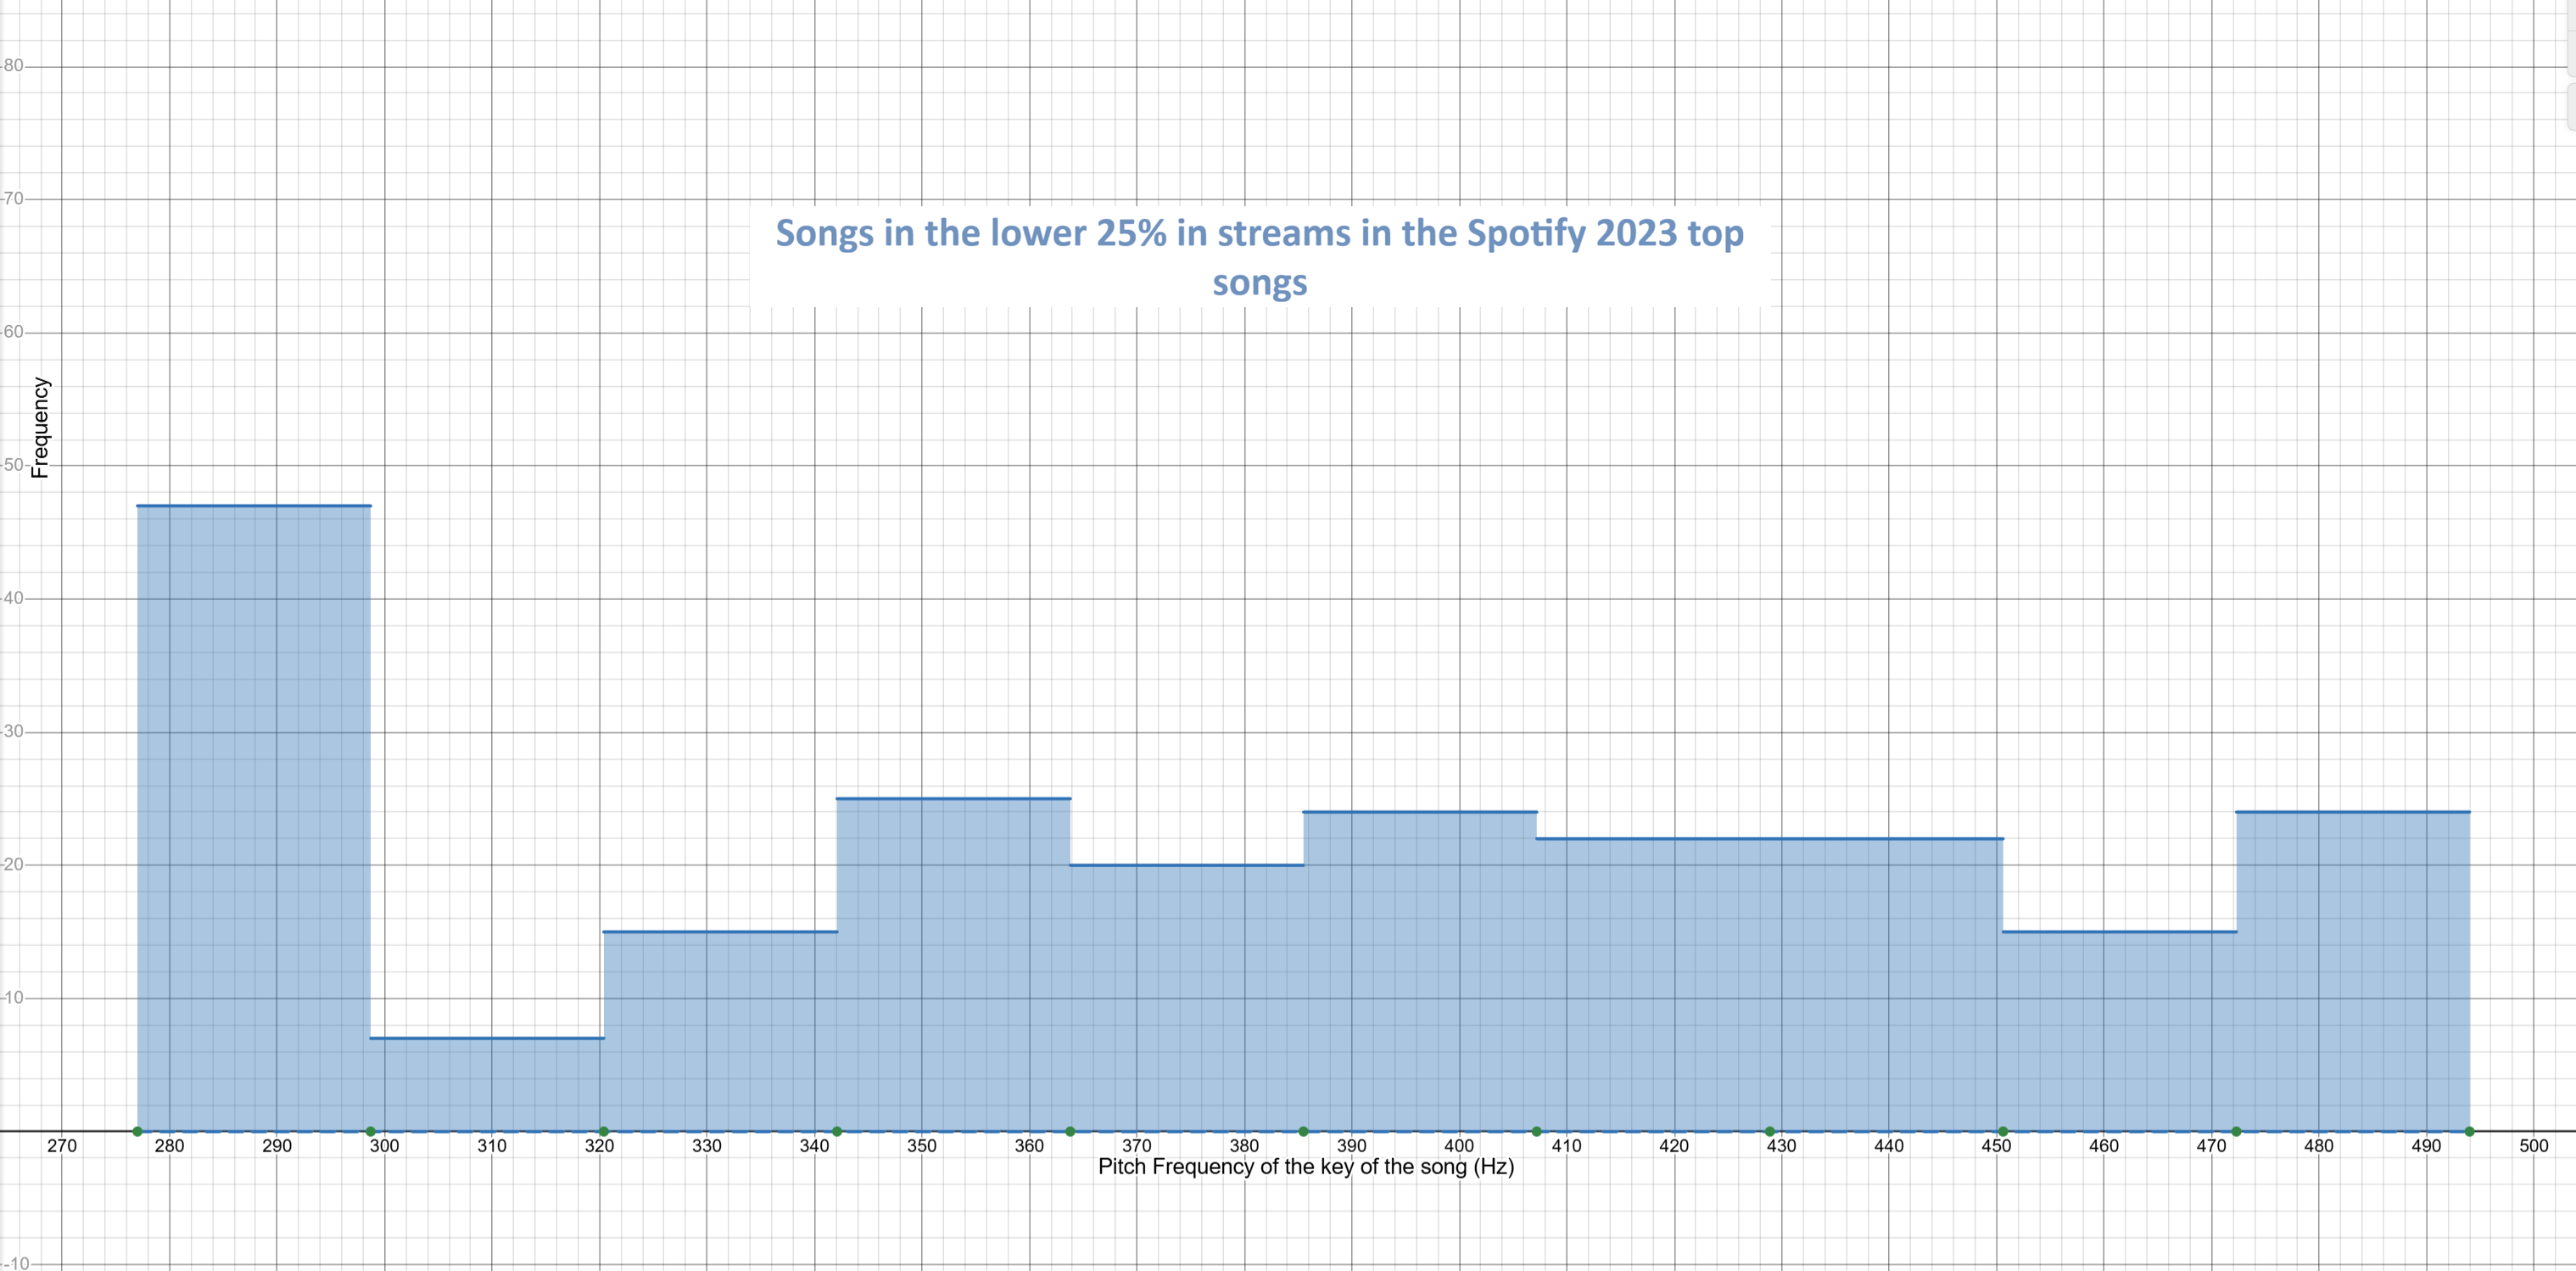

# Conclusion:
#### The most common key in songs from the lower and upper 25% of streams from the list of "Spotify top songs of 2023" is the same. After making histograms for the songs in the 75% percentile and higher (or the upper quartile) and the 25% percentile and lower based on the amount of streams, we can see that both histograms (the scales are the same) have a mode of C#. C#'s pitch is about 290 hertz, and the bin from 278 Hz to 299 Hz is the highest bin in both histograms. There is a smaller frequency of the key C# in the lower 25% of song streams than in the higher 25% of song streams, but C# is the most common key regardless. 